In [1]:
import sys
import os
import re
# 1. Dynamically inject the local venv packages into Python path
# This bypasses the VS Code kernel selection bug
LOCAL_VENV_PATH = os.path.join("..", "venv", "Lib", "site-packages")
if os.path.exists(LOCAL_VENV_PATH):
    sys.path.insert(0, os.path.abspath(LOCAL_VENV_PATH))
    print("[SUCCESS] Local venv site-packages path injected into memory!")

# 2. Try to import pandas to verify if it works now
try:
    import pandas as pd
    print(f"[SUCCESS] Pandas library loaded correctly. Version: {pd.__version__}")
    
    # 3. Test loading our project data
    DATA_PATH = os.path.join("..", "data", "raw", "GermanCredit.csv")
    if os.path.exists(DATA_PATH):
        df = pd.read_csv(DATA_PATH)
        print(f"[SUCCESS] Dataset loaded! Dimensions: {df.shape}")
    else:
        print(f"[ERROR] Could not find 'GermanCredit.csv' at: {DATA_PATH}")
except ImportError:
    print("[ERROR] Pandas is not installed in the current environment path.")


[SUCCESS] Local venv site-packages path injected into memory!
[SUCCESS] Pandas library loaded correctly. Version: 2.2.2
[SUCCESS] Dataset loaded! Dimensions: (1000, 21)


In [44]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import numpy as np
import lightgbm as lgb
import xgboost as xgb
import joblib

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import confusion_matrix
from sklearn.ensemble import RandomForestClassifier


# Phase 1: Data Loading and Structural Inspection

In this section, we will load the German Credit Risk dataset and analyze its structural integrity, identifying data types and the distribution of our target variable (`credit_risk`).


In [3]:
print("---- DataFrame Structural Summary ----")
df.info()

---- DataFrame Structural Summary ----
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   status                   1000 non-null   object
 1   duration                 1000 non-null   int64 
 2   credit_history           1000 non-null   object
 3   purpose                  1000 non-null   object
 4   amount                   1000 non-null   int64 
 5   savings                  1000 non-null   object
 6   employment_duration      1000 non-null   object
 7   installment_rate         1000 non-null   int64 
 8   personal_status_sex      1000 non-null   object
 9   other_debtors            1000 non-null   object
 10  present_residence        1000 non-null   int64 
 11  property                 1000 non-null   object
 12  age                      1000 non-null   int64 
 13  other_installment_plans  1000 non-null   object
 14  ho

In [4]:
# Calculate the absolute and percentage distributions fo the target variable
target_distribution = df['credit_risk'].value_counts()

In [5]:
target_percentage = df['credit_risk'].value_counts(normalize=True) * 100

In [6]:
print(target_distribution)
print(target_percentage)

credit_risk
1    700
0    300
Name: count, dtype: int64
credit_risk
1    70.0
0    30.0
Name: proportion, dtype: float64


# Phase 2: Exploratory Data Analysis (EDA) - Categorical Features

In this section, we isolate and analyze all categorical columns (`object` type) to understand their unique values and distributions before applying encoding techniques.


In [7]:
# Select and display only the categorical columns
categorical_cols = df.select_dtypes(include=["object"]).columns

In [8]:
print(f"Total categorical features found: {len(categorical_cols)}")
print(f'\nList of categorical features: ')
print(list(categorical_cols))

Total categorical features found: 13

List of categorical features: 
['status', 'credit_history', 'purpose', 'savings', 'employment_duration', 'personal_status_sex', 'other_debtors', 'property', 'other_installment_plans', 'housing', 'job', 'telephone', 'foreign_worker']


In [9]:
# 1. Identify all categorical columns (object type)
categorical_cols = df.select_dtypes(include=["object"]).columns

# 2. Print the unique values for the first 3 categorical features to inspect them
print("--- Inspecting Sample Categorical Features ---")
for col in list(categorical_cols)[:3]:
    print(f"\nUnique values for column '{col}':")
    print(df[col].unique())


--- Inspecting Sample Categorical Features ---

Unique values for column 'status':
['... < 100 DM' '0 <= ... < 200 DM' 'no checking account'
 '... >= 200 DM / salary for at least 1 year']

Unique values for column 'credit_history':
['critical account/other credits existing'
 'existing credits paid back duly till now'
 'delay in paying off in the past'
 'no credits taken/all credits paid back duly'
 'all credits at this bank paid back duly']

Unique values for column 'purpose':
['domestic appliances' 'retraining' 'radio/television' 'car (new)'
 'car (used)' 'others' 'repairs' 'education' 'furniture/equipment'
 'business']


## 2.1.1 Analyzing Credit History vs Credit Risk

I will now create a cross-tabulation between `credit_history` and our target variable `credit_risk` to analyze how past payment behavior impacts the final classification.


In [10]:
# Cerate a corsso-tabulation between credit history and credit risk
history_vs_risk = pd.crosstab(df["credit_history"], df["credit_risk"], normalize="index") * 100

In [11]:
# Display the resuylt sorted by bad payers percentage(class 0)
print('---- Credit History vs Credit Risk (%) ----')
print(history_vs_risk.round(2))

---- Credit History vs Credit Risk (%) ----
credit_risk                                      0      1
credit_history                                           
all credits at this bank paid back duly      57.14  42.86
critical account/other credits existing      17.06  82.94
delay in paying off in the past              31.82  68.18
existing credits paid back duly till now     31.89  68.11
no credits taken/all credits paid back duly  62.50  37.50


## 2.1.2 Analyzing Employment Duration vs Credit Risk

I analyze how the length of time a client has been employed impacts their credit risk profile using a normalized cross-tabulation.


In [12]:
# Cross-tabulate employment duration with the credit risk target
employment_vs_risk = pd.crosstab(df['employment_duration'], df['credit_risk'], normalize='index') * 100

In [13]:
print('---- Employment Duration vs Credit Risk (%) ----')
print(employment_vs_risk.round(2))

---- Employment Duration vs Credit Risk (%) ----
credit_risk              0      1
employment_duration              
... < 1 year         40.70  59.30
... >= 7 years       25.30  74.70
1 <= ... < 4 years   30.68  69.32
4 <= ... < 7 years   22.41  77.59
unemployed           37.10  62.90


### 2.1.3 Housing Status vs Credit Risk Analysis

In this step, I will cross-tabulate the `housing` variable against the `credit_risk` target. The objective is to understand how property ownership (rented, owned, or free housing) correlates with credit default rates.


In [14]:
# Analyze the relationship between housing types and credit risk
housing_vs_risk = pd.crosstab(df["housing"], df["credit_risk"], normalize="index") * 100

print("--- Housing Status vs Credit Risk (%) ---")
print(housing_vs_risk.round(2))


--- Housing Status vs Credit Risk (%) ---
credit_risk      0      1
housing                  
for free     40.74  59.26
own          26.09  73.91
rent         39.11  60.89


### 2.2.1 Data Visualization: Credit History vs Credit Risk

I will now generate a stacked bar chart to visually demonstrate how a client's credit history correlates with their probability of default, transforming the previous cross-tabulation into an executive-level chart.


In [15]:
# 1. Reuse the corrs-tabulation data we calculated before
history_vs_risk = pd.crosstab(df['credit_history'], df['credit_risk'], normalize= "index") * 100

In [16]:
# 2. Set the aesthetic style of the plot 
sns.set_theme(style="whitegrid")

(array([0, 1, 2, 3, 4]),
 [Text(0, 0, 'all credits at this bank paid back duly'),
  Text(1, 0, 'critical account/other credits existing'),
  Text(2, 0, 'delay in paying off in the past'),
  Text(3, 0, 'existing credits paid back duly till now'),
  Text(4, 0, 'no credits taken/all credits paid back duly')])

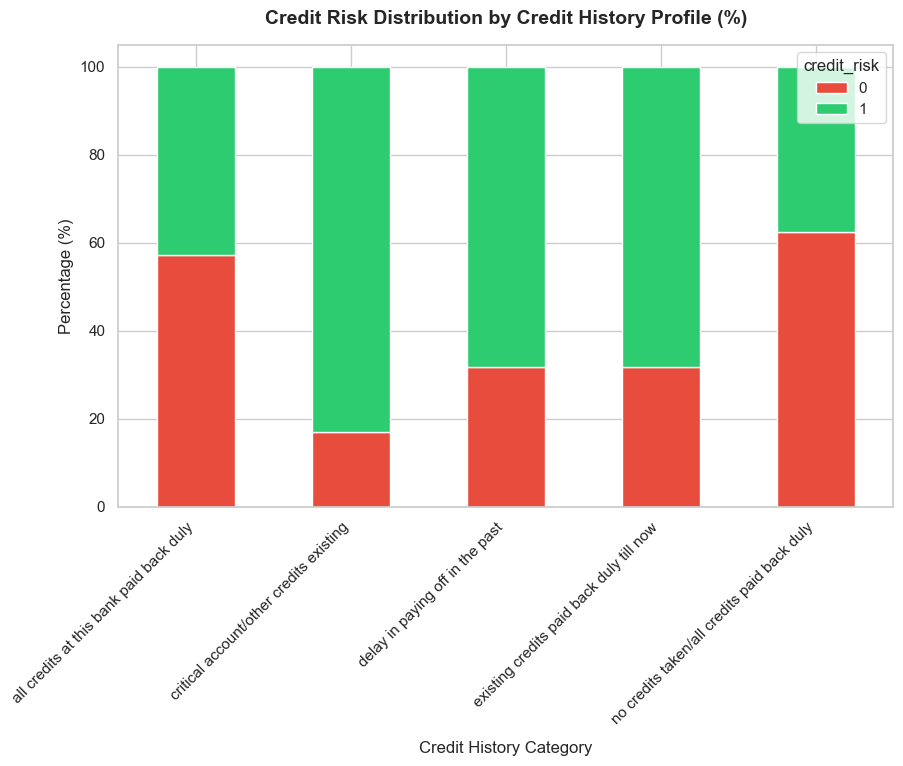

In [17]:
# 3. Plot the stacked bar chart
# Class 0 (bad) and Class 1 (good)
history_vs_risk.plot(kind="bar", stacked=True, color=["#e74c3c", "#2ecc71"], figsize=(10, 6))

# 4. Add professional labels and titles
plt.title("Credit Risk Distribution by Credit History Profile (%)", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Credit History Category", fontsize=12, labelpad=10)
plt.ylabel("Percentage (%)", fontsize=12)
plt.xticks(rotation=45, ha="right")

## Phase 2.3: Exploratory Data Analysis (EDA) - Numerical Features

I will now isolate the numerical columns in the dataset to inspect their descriptive statistics. The focus is to identify the average credit amount requested and the age profile of borrowers.


In [18]:
# Select only numerical features and display their summary statistics
numerical_summary = df.describe()
print(numerical_summary.round(2))

       duration    amount  installment_rate  present_residence      age  \
count   1000.00   1000.00           1000.00            1000.00  1000.00   
mean      20.90   3271.26              2.97               2.84    35.55   
std       12.06   2822.74              1.12               1.10    11.38   
min        4.00    250.00              1.00               1.00    19.00   
25%       12.00   1365.50              2.00               2.00    27.00   
50%       18.00   2319.50              3.00               3.00    33.00   
75%       24.00   3972.25              4.00               4.00    42.00   
max       72.00  18424.00              4.00               4.00    75.00   

       number_credits  people_liable  credit_risk  
count         1000.00        1000.00      1000.00  
mean             1.41           1.16         0.70  
std              0.58           0.36         0.46  
min              1.00           1.00         0.00  
25%              1.00           1.00         0.00  
50%         

### 2.3.1 Numerical Metrics Segmented by Credit Risk

I will group the dataset by the target variable `credit_risk` to analyze the mean values of numerical attributes. This helps to check if higher credit amounts are associated with high-risk profiles.


In [19]:
# group by risk profile and calculate the avarage for numerical features
risk_grouped_means = df.groupby("credit_risk").mean(numeric_only=True)


In [20]:
# select and print only amount and age columns to check the profile
print('---- Averege Numerical Values by Risk Group (0 = bad, 1= Good) ---- ')
print(risk_grouped_means[['amount','age']].round(2))

---- Averege Numerical Values by Risk Group (0 = bad, 1= Good) ---- 
              amount    age
credit_risk                
0            3938.13  33.96
1            2985.46  36.22


### 2.3.2 Data Visualization: Age Distribution by Credit Risk

I will create a histogram overlay to visualize the age distribution of both good and bad payers, analyzing if younger applicants represent a higher concentration of default risk.


Text(0, 0.5, 'Count of Clients')

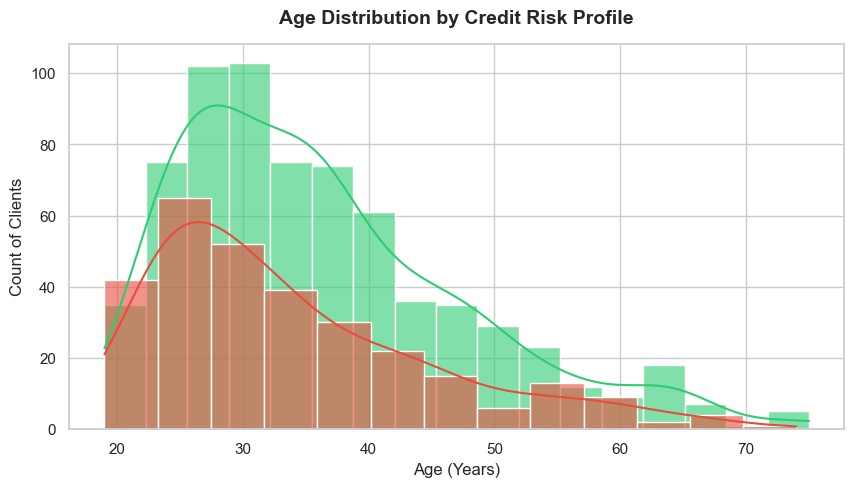

In [21]:
# set the figure size
plt.figure(figsize=(10,5))

# Plot the distribution for good payers (1)
sns.histplot(data=df[df["credit_risk"] == 1], x="age", color="#2ecc71", label="Good Payer (1)", kde=True, alpha=0.6)

# Plot the distribution for bad payers (0)
sns.histplot(data=df[df["credit_risk"] == 0], x="age", color="#e74c3c", label="Bad Payer (0)", kde=True, alpha=0.6)

# Add titles and labels
plt.title("Age Distribution by Credit Risk Profile", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Age (Years)", fontsize=12)
plt.ylabel("Count of Clients", fontsize=12)

# Phase 3: Feature Engineering - Categorical Encoding

In this phase, I will transform the 13 categorical features into numeric formats. I will use One-Hot Encoding for nominal variables and prepare the final dataset for the Machine Learning model.


In [22]:
# Apply One-Hot Encoding to all categoical columns and drop the first category
df_encoded = pd.get_dummies(df, drop_first=True, dtype=int)


print('---- Features Transformation Summary ----')
print(f'Original shape: {df.shape}')
print(f'New encoded shape: {df_encoded.shape}')
print('\nPreview of the first 5 new columns:')
print(list(df_encoded.columns)[20:25])

---- Features Transformation Summary ----
Original shape: (1000, 21)
New encoded shape: (1000, 49)

Preview of the first 5 new columns:
['purpose_others', 'purpose_radio/television', 'purpose_repairs', 'purpose_retraining', 'savings_... >= 1000 DM']


### 3.1.1 Splitting Features (X) and Target (y)

I will now isolate the target variable `credit_risk` into vector `y` and store all predictive features in matrix `X` to prepare the data for the train-test split.


In [23]:
# Separate target variable (y) from independent feature (x)
X = df_encoded.drop(columns=["credit_risk"])
y = df_encoded['credit_risk']

In [24]:
print('--- Matrix Separation Summary ----')
print(f'feature matrix (X) shape: {X.shape}')
print(f'Target vector (y) shape: {y.shape}')

--- Matrix Separation Summary ----
feature matrix (X) shape: (1000, 48)
Target vector (y) shape: (1000,)


# Phase 4: Train-Test Split

In this phase, I will split the features matrix (X) and the target vector (y) into training (80%) and testing (20%) sets. This guarantees we can evaluate the model on unseen data and prevent overfitting.


In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

In [26]:
print('---- Train test Split Completed ----')
print(f"X_train size (Questions for study): {X_train.shape}")
print(f"X_test size (Questions for the exam): {X_test.shape}")
print(f"y_train size (Answers for study): {y_train.shape}")
print(f"y_test size (Answers for the exam evaluation): {y_test.shape}")

---- Train test Split Completed ----
X_train size (Questions for study): (800, 48)
X_test size (Questions for the exam): (200, 48)
y_train size (Answers for study): (800,)
y_test size (Answers for the exam evaluation): (200,)


# Phase 5: Model Training - Logistic Regression

In this phase, I will initialize and train a classic Logistic Regression model using the 800 training samples. I will set the class weight to 'balanced' to handle the 70/30 distribution imbalance.


In [27]:
# 1. initialize the model with maximum iterations and balanced weights
model = LogisticRegression(class_weight='balanced', max_iter=3000, random_state=42)

warnings.filterwarnings("ignore")

# 2. Train the model using the training question (X_train) and answers (y_train)
model.fit(X_train, y_train)

print("--- Logistic Regression Model Training Completed ---")
print(f"Model coefficients shape: {model.coef_.shape}")
print("[SUCCESS] The model has learned the mathematical weights for credit risk!")

--- Logistic Regression Model Training Completed ---
Model coefficients shape: (1, 48)
[SUCCESS] The model has learned the mathematical weights for credit risk!


# Phase 6: Model Evaluation

In this phase, I will generate predictions using the 200 unseen testing samples (`X_test`). I will print the classification performance metrics translated into percentages to evaluate accuracy, precision, and recall.


In [28]:
# 1. Genarate predictions for the 200 unseen test samples
y_pred = model.predict(X_test)

# 2. Calculate metrics and convert the to percentages
accuracy_pct = accuracy_score(y_test, y_pred) *100
precision_pct = precision_score(y_test, y_pred) * 100
recall_pct = recall_score(y_test, y_pred) * 100

In [29]:
print('--- Model Performance Metrics (%) ---')
print(f'Overall Accuracy: {accuracy_pct:.2f}%')
print(f'Precision (Good Payer confdence): {precision_pct:.2f}%')
print(f'Recall (Sensitivity to capture Good Payers): {recall_pct:.2f}%')

--- Model Performance Metrics (%) ---
Overall Accuracy: 67.50%
Precision (Good Payer confdence): 83.78%
Recall (Sensitivity to capture Good Payers): 66.43%


### 6.1.1 Data Visualization: Normalized Confusion Matrix

I will now generate a visual and normalized Confusion Matrix using Seaborn to plot the exact percentages of True Positives, True Negatives, False Positives, and False Negatives.


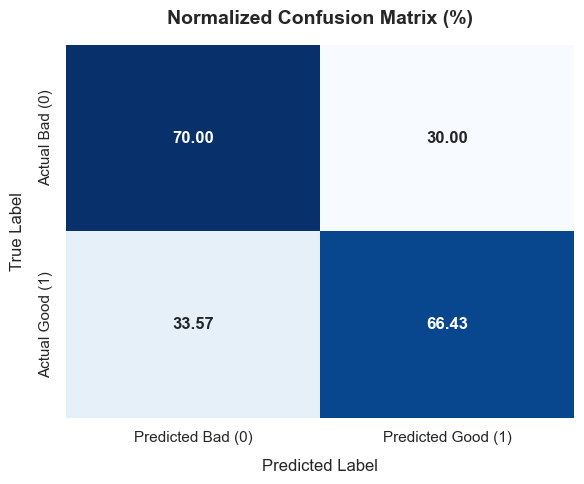

In [30]:
# 1. Compute the raw confusion matrix
cm = confusion_matrix(y_test, y_pred)

# 2. normalize the matrix to show percentages within each true class row
cm_pct = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis] * 100

# 3. Setup the visual design using Seaborn heatmap
plt.figure(figsize=(6,5))
sns.heatmap(
    cm_pct,
    annot=True,
    fmt=".2f",
    cmap='Blues',
    cbar=False,
    xticklabels=["Predicted Bad (0)", "Predicted Good (1)"],
    yticklabels=["Actual Bad (0)", "Actual Good (1)"],
    annot_kws={"size": 12, "weight": "bold"},
)

# 4. Add titles and labels
plt.title("Normalized Confusion Matrix (%)", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Predicted Label", fontsize=12, labelpad=10)
plt.ylabel("True Label", fontsize=12, labelpad=10)

plt.tight_layout()
plt.show()

# Phase 7: Model Upgrades - Random Forest Classifier

In this phase, I will train a Random Forest Classifier to check if an ensemble tree-based model can outperform the baseline Logistic Regression in detecting default risk.



In [31]:
# 1. Initialize the Random Forest with balanced weight and 200 trees 
rf_model = RandomForestClassifier(
    n_estimators=200, class_weight='balanced', random_state=42
)

# 2. train the tree-based model
rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

In [32]:
print("--- Random Forest Classifier Training Completed ---")
print(f"Total trees generated: {len(rf_model.estimators_)}")
print("[SUCCESS] The forest has grown and learned the credit patterns!")

--- Random Forest Classifier Training Completed ---
Total trees generated: 200
[SUCCESS] The forest has grown and learned the credit patterns!


### 7.1.1 Evaluating Random Forest Performance

I will now generate predictions using the trained Random Forest model on the 200 test samples and compute the accuracy, precision, and recall percentages.


In [33]:
# 1. Generate predictions using the random forest model
y_pred_rf = rf_model.predict(X_test)

# 2. Calculate percentages for the forest model
rf_accuracy = accuracy_score(y_test, y_pred_rf) *100
rf_precision = precision_score(y_test, y_pred_rf) *100
rf_recall = recall_score(y_test, y_pred_rf) *100

print(' ---- Random Fores Performance Metrics (%) ----')
print(f"Overall Accuracy: {rf_accuracy:.2f}%")
print(f"Precision (Good Payer confidence): {rf_precision:.2f}%")
print(f"Recall (Sensitivity to capture Good Payers): {rf_recall:.2f}%")

 ---- Random Fores Performance Metrics (%) ----
Overall Accuracy: 72.00%
Precision (Good Payer confidence): 75.61%
Recall (Sensitivity to capture Good Payers): 88.57%


### 7.1.2 Data Visualization: Random Forest Confusion Matrix

I will generate a normalized confusion matrix heatmap for the Random Forest model to inspect the changes in accurate predictions and errors.


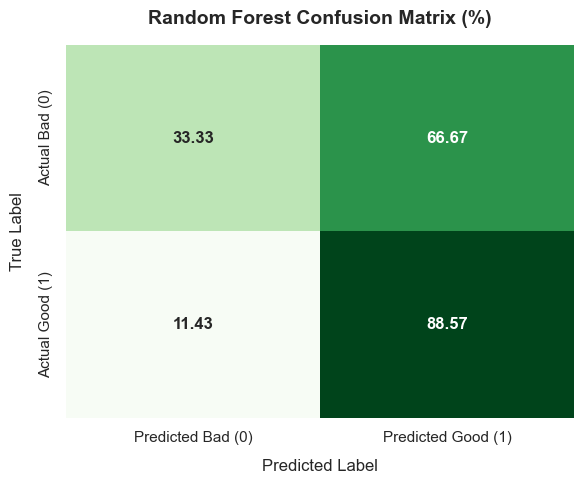

In [34]:
# 1. Compute the raw confusion matrix for Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)

# 2. Normalize the matrix to show percentages within each true class row
cm_rf_pct = cm_rf.astype("float") / cm_rf.sum(axis=1)[:, np.newaxis] * 100

# 3. Setup the visual design using Seaborn heatmap (using a green color palette)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_rf_pct,
    annot=True,
    fmt=".2f",
    cmap="Greens",
    cbar=False,
    xticklabels=["Predicted Bad (0)", "Predicted Good (1)"],
    yticklabels=["Actual Bad (0)", "Actual Good (1)"],
    annot_kws={"size": 12, "weight": "bold"},
)

# 4. Add titles and labels
plt.title(
    "Random Forest Confusion Matrix (%)", fontsize=14, fontweight="bold", pad=15
)
plt.xlabel("Predicted Label", fontsize=12, labelpad=10)
plt.ylabel("True Label", fontsize=12, labelpad=10)

plt.tight_layout()
plt.show()

# Phase 8: Feature Importance Analysis

In this phase, I will extract and visualize the feature importance weights from the trained Random Forest model. This analysis reveals which financial and demographic attributes carry the most predictive power for credit risk assessment.


In [35]:
# 1. Extract feature importances from the random forest model
importances = rf_model.feature_importances_

# 2. Create a dataframe linking features to their respective importance weights
feature_importances_df = pd.DataFrame(
    {"Feature": X.columns, "Importance (%)": importances * 100}
)

# 3. Sort the dataframe by importance in descending order and select the top 10
top_10_features = feature_importances_df.sort_values(
    by="Importance (%)", ascending=False
).head(10)

print("--- Top 10 Most Important Features in Credit Risk Model ---")
print(top_10_features.round(2).to_string(index=False))


--- Top 10 Most Important Features in Credit Risk Model ---
                                               Feature  Importance (%)
                                                amount           10.85
                                              duration            8.78
                                                   age            8.55
                            status_no checking account            8.39
                                     present_residence            3.97
                                      installment_rate            3.87
credit_history_critical account/other credits existing            2.83
                          other_installment_plans_none            2.19
                                    purpose_car (used)            2.09
                                         telephone_yes            2.08


### 8.1.1 Visualizing Top 10 Feature Importances

I will now plot a horizontal bar chart showing the top 10 features sorted by their predictive importance score in the Random Forest model.


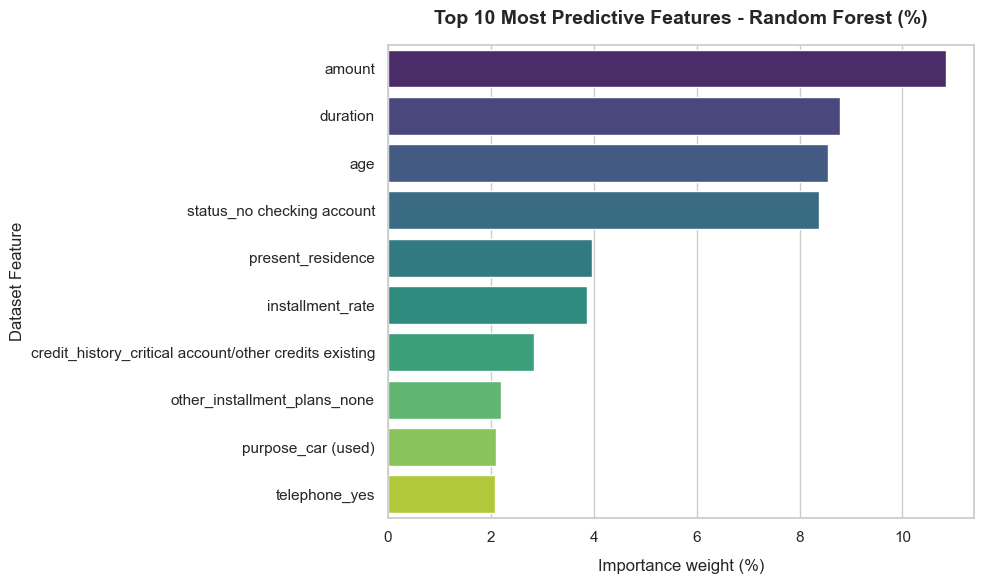

In [36]:
#1. Setup the plot Layout style and size
plt.figure(figsize=(10,6))
sns.set_theme(style="whitegrid")
#2. Create the horizontal bar plot using the top 10 feature dataframe
sns.barplot(
    data=top_10_features,
    x="Importance (%)",
    y="Feature",
    palette="viridis",
    hue="Feature",
    legend=False,
)
#3. Add executive titles and Labels
plt.title(
    "Top 10 Most Predictive Features - Random Forest (%)",
    fontsize=14,
    fontweight="bold",
    pad=15
)
plt.xlabel("Importance weight (%)", fontsize=12, labelpad=10)
plt.ylabel("Dataset Feature", fontsize=12)

# 4. Clean Layout and render the image
plt.tight_layout()
plt.show()

# Phase 9: Advanced Ensemble Modeling - LightGBM Classifier

In this phase, I will initialize and train a LightGBM Classifier. This gradient boosting model utilizes sequential tree building to optimize loss weights and handle our 70/30 class imbalance dynamically.


In [37]:
# 1. Standardize column names by replacing forbidden symbols with underscores
clean_columns = [
    re.sub(r"[\[\]<>\/\s,.:;()+=\-*&%$#@!\"']+", "_", col) for col in X.columns
]

# 2. Rebuild the train and test dataframes with the freshly sanitized column names
X_train_clean = X_train.copy()
X_test_clean = X_test.copy()

X_train_clean.columns = clean_columns
X_test_clean.columns = clean_columns

# 3. Initialize LightGBM with robust parameters
lgb_model = lgb.LGBMClassifier(
    is_unbalance=True, random_state=42, verbose=-1, n_estimators=150
)

# 4. Train the model safely using the clean datasets
lgb_model.fit(X_train_clean, y_train)

print("--- LightGBM Classifier Training Completed ---")
print(f"Total boosting rounds executed: {lgb_model.n_estimators}")
print("[SUCCESS] The LightGBM model has finished training sequencially!")


--- LightGBM Classifier Training Completed ---
Total boosting rounds executed: 150
[SUCCESS] The LightGBM model has finished training sequencially!


### 9.1.1 Evaluating LightGBM Performance

I will now generate predictions using the trained LightGBM model on the sanitized test samples (`X_test_clean`) and compute the accuracy, precision, and recall percentages.


In [38]:
# 1. Generate predictions using the LightGBM model on the clean test data
y_pred_lgb = lgb_model.predict(X_test_clean)

# 2. Calculate percentages for the boosting model
lgb_accuracy = accuracy_score(y_test, y_pred_lgb) * 100
lgb_precision = precision_score(y_test, y_pred_lgb) * 100
lgb_recall = recall_score(y_test, y_pred_lgb) * 100

#print("--- LightGBM Performance Metrics (%) ---")
print(f"Overall Accuracy: {lgb_accuracy:.2f}%")
print(f"Precision (Good Payer confidence): {lgb_precision:.2f}%")
print(f"Recall (Sensitivity to capture Good Payers): {lgb_recall:.2f}%")

Overall Accuracy: 74.00%
Precision (Good Payer confidence): 81.43%
Recall (Sensitivity to capture Good Payers): 81.43%


# Phase 10: Advanced Ensemble Modeling - XGBoost Classifier

In this phase, I will train an XGBoost Classifier on the sanitized dataset. I will utilize the `scale_pos_weight` parameter to balance the loss function against our 70/30 credit risk distribution.


In [40]:
# 1. Calculae the scale weith for unbalanced data (approx 30% bad / 70% good)
ratio = (y_train == 0).sum() / (y_train == 1).sum()

# 2. Initialize the XGBoost Classifier
xgb_model = xgb.XGBClassifier(scale_pos_weight=ratio, random_state=42, eval_metric="logloss")

# 3. Train the model using the clean training data
xgb_model.fit(X_train_clean, y_train)

print("--- XGBoost Classifier Training Completed ---")
print(f"Model trained with scale_pos_weight ratio: {ratio:.2f}")
print("[SUCCESS] The XGBoost model has finished training sequencially!")


--- XGBoost Classifier Training Completed ---
Model trained with scale_pos_weight ratio: 0.43
[SUCCESS] The XGBoost model has finished training sequencially!


### 10.1.1 Evaluating XGBoost Performance

I will now generate predictions using the trained XGBoost model on the sanitized test samples (`X_test_clean`) and compute the accuracy, precision, and recall percentages for final model comparison.


In [41]:
# 1. generate predictions using the XGBoost model on the clean test data
y_pred_xgb = xgb_model.predict(X_test_clean)

# 2. Calculate percentages for the XGBoost model
xgb_accuracy = accuracy_score(y_test, y_pred_xgb) * 100
xgb_precision = precision_score(y_test, y_pred_xgb) * 100
xgb_recall = recall_score(y_test, y_pred_xgb) * 100

print("--- XGBoost Performance Metrics (%) ---")
print(f"Overall Accuracy: {xgb_accuracy:.2f}%")
print(f"Precision (Good Payer confidence): {xgb_precision:.2f}%")
print(f"Recall (Sensitivity to capture Good Payers): {xgb_recall:.2f}%")

--- XGBoost Performance Metrics (%) ---
Overall Accuracy: 71.00%
Precision (Good Payer confidence): 82.03%
Recall (Sensitivity to capture Good Payers): 75.00%


### 10.1.2 Data Visualization: XGBoost Confusion Matrix

I will generate the normalized confusion matrix for the XGBoost model using a red color palette to inspect its final classification errors.


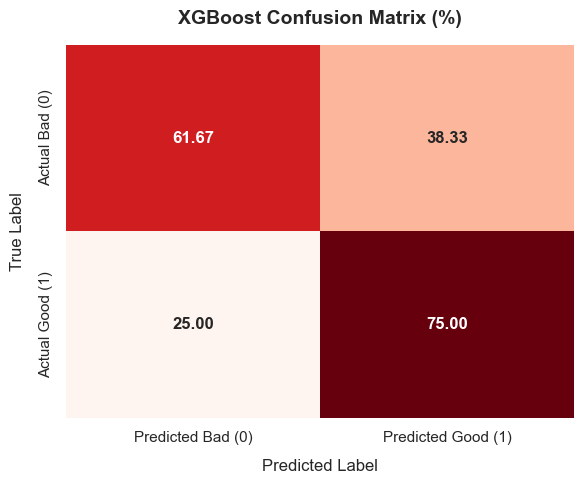

In [42]:
# 1. Compute the raw confusion matrix for XGBoost 
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

# 2. Normalize the matrix raws to percentages
cm_xgb_pct = cm_xgb.astype("float") / cm_xgb.sum(axis=1)[:, np.newaxis] * 100

# 3. Setup the visual design using Seaborn heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_xgb_pct,
    annot=True,
    fmt=".2f",
    cmap="Reds",
    cbar=False,
    xticklabels=["Predicted Bad (0)", "Predicted Good (1)"],
    yticklabels=["Actual Bad (0)", "Actual Good (1)"],
    annot_kws={"size": 12, "weight": "bold"},
)

# 4. Add titles and labels
plt.title("XGBoost Confusion Matrix (%)", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Predicted Label", fontsize=12, labelpad=10)
plt.ylabel("True Label", fontsize=12, labelpad=10)

plt.tight_layout()
plt.show()

# Phase 11: Model Serialization and Export

In this phase, I will serialize and export our champion model (LightGBM) using the `joblib` library. This creates a persistent binary file, allowing us to load the model in our future FastAPI production environment without needing to retrain it.


In [46]:
# 1. Create a professional deployment directory for our binaries
MODEL_DIR = os.path.join("..", "models")
os.makedirs(MODEL_DIR, exist_ok=True)

# 2. Define the destination file path for the champion model
MODEL_FILE_PATH = os.path.join(MODEL_DIR, "credit_lgb_champion.joblib")

# 3. Serialize and save the trained LightGBM model to the hard drive
joblib.dump(lgb_model, MODEL_FILE_PATH)

print("--- Model Serialization Completed ---")
if os.path.exists(MODEL_FILE_PATH):
    file_size_mb = os.path.getsize(MODEL_FILE_PATH) / (1024 * 1024)
    print(f"[SUCCESS] Champion LightGBM model successfully exported!")
    print(f"File Location: {MODEL_FILE_PATH}")
    print(f"File Size: {file_size_mb:.2f} MB")


--- Model Serialization Completed ---
[SUCCESS] Champion LightGBM model successfully exported!
File Location: ..\models\credit_lgb_champion.joblib
File Size: 0.49 MB
